<a href="https://colab.research.google.com/github/sondosafme04/Bubble-Sheet-Grader/blob/main/Bubble_Sheet_Gradrer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install tensorflow gradio seaborn scikit-learn matplotlib
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
import gradio as gr
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# الفولدر الرئيسي
base_path = "/content/drive/MyDrive/pattern"
# فولدر الصور
images_path = os.path.join(base_path, "OMR_Image_Resized")
# ملف الـ CSV
csv_path = os.path.join(base_path, "OMR_Ans.csv")

df = pd.read_csv(csv_path)
print(df.head())
image_files = os.listdir(images_path)
print("عدد الصور:", len(image_files))

   Image_ID Q1 Q2 Q3 Q4 Q5 Q6 Q7 Q8 Q9  ... Q21 Q22 Q23 Q24 Q25 Q26 Q27 Q28  \
0       1.0  C  C  C  D  D  C  B  C  A  ...   C   B   B   B   B   C   B   A   
1       2.0  B  B  B  A  C  C  C  C  A  ...   B   B   C   B   C   B   C   B   
2       3.0  A  B  A  A  B  A  A  A  A  ...   B   B   B   B   C   B   B   B   
3       4.0  B  C  C  B  C  C  B  B  A  ...   B   B   B   B   C   D   C   B   
4       5.0  A  B  B  B  B  C  B  B  A  ...   C   B   B   D   C   B   C   C   

  Q29 Q30  
0   A   B  
1   B   B  
2   A   A  
3   A   A  
4   A   B  

[5 rows x 31 columns]
عدد الصور: 145


In [5]:
from sklearn.model_selection import train_test_split

X = df.iloc[:, 0].values
y = df.iloc[:, 1:].values

X_train_names, X_temp, y_train_names, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_valid_names, X_test_names, y_valid_names, y_test_names = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Train:", len(X_train_names))
print("Valid:", len(X_valid_names))
print("Test :", len(X_test_names))

Train: 103
Valid: 22
Test : 23


In [6]:
BUBBLE_SIZE = (32, 32)
CHOICES = 4

def extract_bubble_images(image, row_gap=25):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 1)
    circles = cv2.HoughCircles(blur, cv2.HOUGH_GRADIENT, dp=1, minDist=20, param1=50, param2=20, minRadius=8, maxRadius=22)

    if circles is None: return [], []
    circles = np.round(circles[0, :]).astype("int")
    img_width = image.shape[1]
    col_width = img_width / 3
    def get_col(cx): return int(cx / col_width)
    sorted_circles = sorted(circles, key=lambda c: (get_col(c[0]), c[1], c[0]))

    rows, current_row = [], []
    last_y, last_col = sorted_circles[0][1], get_col(sorted_circles[0][0])
    for cx, cy, r in sorted_circles:
        cur_col = get_col(cx)
        if cur_col != last_col or abs(cy - last_y) > row_gap:
            if current_row: rows.append(sorted(current_row, key=lambda c: c[0]))
            current_row, last_y, last_col = [], cy, cur_col
        current_row.append((cx, cy, r))
    if current_row: rows.append(sorted(current_row, key=lambda c: c[0]))

    rows = [row[:CHOICES] for row in rows if len(row) >= CHOICES]
    bubble_images = []
    for row in rows:
        for (cx, cy, r) in row:
            pad = 5
            x1, y1 = max(0, cx - r - pad), max(0, cy - r - pad)
            x2, y2 = min(image.shape[1], cx + r + pad), min(image.shape[0], cy + r + pad)
            crop = image[y1:y2, x1:x2]
            if crop.size > 0:
                crop = cv2.resize(crop, BUBBLE_SIZE)
                bubble_images.append(crop)
    return bubble_images, rows

In [7]:
NUM_QUESTIONS = 30

def prepare_training_data_from_names(image_names, images_folder):
    features, labels = [], []
    existing_files = os.listdir(images_folder)
    name_map = {os.path.splitext(f)[0]: f for f in existing_files}
    for f in existing_files:
        stem = os.path.splitext(f)[0]
        if stem.isdigit(): name_map[str(int(stem))] = f

    for raw_name in image_names:
        try: stem = str(int(float(str(raw_name))))
        except: stem = str(raw_name).strip()
        fname = name_map.get(stem) or name_map.get(stem.zfill(3))
        if fname is None: continue
        img = cv2.imread(os.path.join(images_folder, fname))
        if img is None: continue
        bubbles, _ = extract_bubble_images(img)
        for b in bubbles:
            gray = cv2.cvtColor(b, cv2.COLOR_BGR2GRAY)
            features.append(gray / 255.0)
            labels.append(1 if np.mean(gray) < 150 else 0)
    return np.array(features).reshape(-1, 32, 32, 1), np.array(labels)

X_train, y_train = prepare_training_data_from_names(X_train_names, images_path)
X_val, y_val = prepare_training_data_from_names(X_valid_names, images_path)
X_test_data, y_test_data = prepare_training_data_from_names(X_test_names, images_path)

In [8]:
model = keras.Sequential([
    layers.Input(shape=(32, 32, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

Epoch 1/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 27s 66ms/step - accuracy: 0.8776 - loss: 0.2658 - val_accuracy: 0.9484 - val_loss: 0.1064
Epoch 2/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 20s 53ms/step - accuracy: 0.9376 - loss: 0.1406 - val_accuracy: 0.9697 - val_loss: 0.0721
Epoch 3/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 20s 54ms/step - accuracy: 0.9509 - loss: 0.1181 - val_accuracy: 0.9852 - val_loss: 0.0490
Epoch 4/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 22s 58ms/step - accuracy: 0.9534 - loss: 0.1077 - val_accuracy: 0.9863 - val_loss: 0.0480
Epoch 5/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 22s 57ms/step - accuracy: 0.9491 - loss: 0.1138 - val_accuracy: 0.9715 - val_loss: 0.0694
Epoch 6/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 20s 54ms/step - accuracy: 0.9506 - loss: 0.1151 - val_accuracy: 0.9640 - val_loss: 0.0746
Epoch 7/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 20s 53ms/step - accuracy: 0.9549 - loss: 0.0972 - val_accuracy: 0.9780 - val_loss: 0.0508
Epoch 8/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - accuracy: 0.9491 - loss: 0.1146 - 

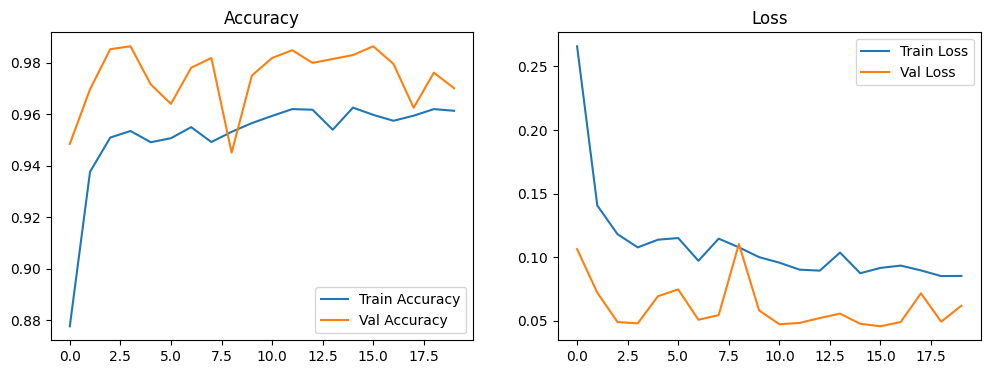

In [9]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    fill_mode='nearest'
)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val),
    epochs=20,
    verbose=1
)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9587 - loss: 0.0885
Test Accuracy: 0.9587
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


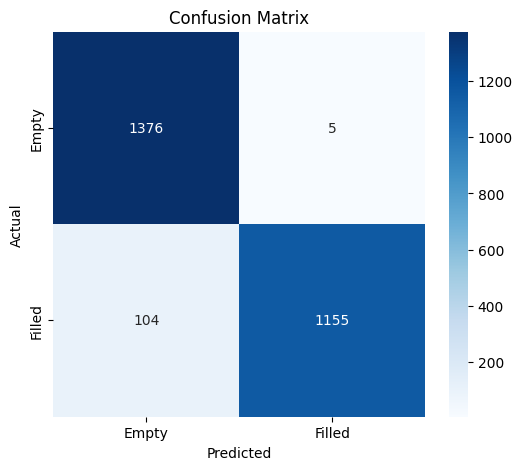

In [10]:
model.save("/content/drive/MyDrive/bubble_detector_model.keras")

# التقييم النهائي
test_loss, test_acc = model.evaluate(X_test_data, y_test_data)
print(f"Test Accuracy: {test_acc:.4f}")

# رسم الـ Confusion Matrix
y_pred = (model.predict(X_test_data) > 0.5).astype(int)
cm = confusion_matrix(y_test_data, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Empty', 'Filled'], yticklabels=['Empty', 'Filled'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [11]:
def extract_correct_answers(answer_key_img):
    bubbles, _ = extract_bubble_images(answer_key_img)
    answers, letters = {}, ['A', 'B', 'C', 'D']
    for q in range(1, NUM_QUESTIONS + 1):
        start = (q - 1) * CHOICES
        for i in range(CHOICES):
            gray = cv2.cvtColor(bubbles[start + i], cv2.COLOR_BGR2GRAY)
            if np.mean(gray) < 150:
                answers[q] = letters[i]
                break
    return answers

def grade_with_trained_model(student_img_path, answer_key_img_path, model):
    student_img = cv2.imread(student_img_path)
    key_img = cv2.imread(answer_key_img_path)
    if student_img is None or key_img is None: return None, "Error loading images"

    bubbles, _ = extract_bubble_images(student_img)
    X_input = np.array([cv2.cvtColor(b, cv2.COLOR_BGR2GRAY) / 255.0 for b in bubbles]).reshape(-1, 32, 32, 1)
    filled = model.predict(X_input, verbose=0).flatten() > 0.5

    student_answers = {}
    letters = ['A', 'B', 'C', 'D']
    for q in range(1, NUM_QUESTIONS + 1):
        start = (q - 1) * CHOICES
        choice = None
        for i in range(CHOICES):
            if (start + i) < len(filled) and filled[start + i]:
                choice = letters[i]
                break
        student_answers[q] = choice

    correct_answers = extract_correct_answers(key_img)
    correct_count, details = 0, []
    for q in range(1, NUM_QUESTIONS + 1):
        stu, cor = student_answers.get(q), correct_answers.get(q)
        is_correct = (stu == cor and stu is not None)
        if is_correct: correct_count += 1
        details.append([q, stu or "—", cor or "—", "✓" if is_correct else "✗"])

    return pd.DataFrame(details, columns=["Question", "Student", "Correct", "Result"]), f"Score: {correct_count}/{NUM_QUESTIONS}"

In [12]:
def gui_grade(student_file, answer_key_file):
    df, msg = grade_with_trained_model(student_file, answer_key_file, model)
    return df, msg

iface = gr.Interface(
    fn=gui_grade,
    inputs=[gr.Image(type="filepath", label="Student Sheet"), gr.Image(type="filepath", label="Answer Key Sheet")],
    outputs=[gr.Dataframe(label="Results"), gr.Textbox(label="Summary")],
    title="Bubble Sheet Grader"
)
iface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://140ff3bc2f5e933245.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
